1- Loading the data from kaggle

2- Load labels csv for labels that contain image ID and breed

3- Checking the breed count

4- One-hot encoding on labels dats prediction column

5- Load the images, convert them to an array and normalize them

6- Check the shape and size of x and y data

7- Building the model network architecture

8- Split the data and fit it into the model and create an accuracy plot

In [1]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"ninabordo03","key":"5f21ac78756c02e2991c8b795d0f79d7"}'}

In [2]:
# install the kaggle API client
!pip install -q kaggle

In [3]:
# The Kaggle API client expects this file to be in ~/.kaggle, so move it there
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle.json
# This permissions change avoids a warning on Kaggle tool startup
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


Setting up Kaggle using Kaggle API

In [4]:
!mkdir dog_dataset
%cd dog_dataset

/content/dog_dataset


To store the data we will create a new directory and make it as current working directory

In [5]:
!kaggle datasets list -s dogbreedidfromcomp

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


Searching Kaggle for the required dataset using search option(-s) with title 'dogbreedidfromcomp'. We can also use different search options like searching competitions, notebooks, kernels, datasets, etc

In [6]:
# Downloading dataset and coming out of directory
!kaggle datasets download catherinehorng/dogbreedidfromcomp
%cd ..

Dataset URL: https://www.kaggle.com/datasets/catherinehorng/dogbreedidfromcomp
License(s): unknown
100% 691M/691M [00:10<00:00, 67.0MB/s]

/content


After searching the data next step would be downloading the data into collab notebook using references found in search option

In [7]:
# Unzipping downloaded file and removing unusable file
!unzip dog_dataset/dogbreedidfromcomp.zip -d dog_dataset
!rm dog_dataset/dogbreedidfromcomp.zip
!rm dog_dataset/sample_submission.csv

Streaming output truncated to the last 5000 lines.
  inflating: dog_dataset/train/83bc62b0fffa99a9c94ba0b67a5f7395.jpg  
  inflating: dog_dataset/train/83bcff6b55ee179a7c123fa6103c377a.jpg  
  inflating: dog_dataset/train/83be6d622ab74a5e7e08b53eb8fd566a.jpg  
  inflating: dog_dataset/train/83c2d7419b0429b9fe953bc1b6cddbec.jpg  
  inflating: dog_dataset/train/83cf7d7cd2a759a93e2ffd95bea9c6fb.jpg  
  inflating: dog_dataset/train/83d405858f0931722ef21e8ac0adee4d.jpg  
  inflating: dog_dataset/train/83d4125a4c3c7dc5956563276cb1cd74.jpg  
  inflating: dog_dataset/train/83f0bb565b2186dbcc6a9d009cb26ff2.jpg  
  inflating: dog_dataset/train/83fad0718581a696132c96c166472627.jpg  
  inflating: dog_dataset/train/83fbbcc9a612e3f712b1ba199da61f20.jpg  
  inflating: dog_dataset/train/8403d8936430c2f05ab7d74d23c2c0cb.jpg  
  inflating: dog_dataset/train/8406d837b2d7fac1c3cd621abb4c4f9e.jpg  
  inflating: dog_dataset/train/840b67d26e5e43f8eb6430f62d4ba1ac.jpg  
  inflating: dog_dataset/train/840db91b

In [8]:
# Important library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from keras.preprocessing import image
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D
from keras.optimizers import Adam

In [9]:
labels_all = pd.read_csv('dog_dataset/labels.csv')
labels_all.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [10]:
breed_counts = labels_all['breed'].value_counts()
breed_counts.head()

,count
breed,
scottish_deerhound,126
maltese_dog,117
afghan_hound,116
entlebucher,115
bernese_mountain_dog,114


In [11]:
# selecting first 3 breeds due to computation power
selected = ['scottish_deerhound', 'maltese_dog', 'afghan_hound']
labels = labels_all[(labels_all['breed'].isin(selected))]
labels = labels.reset_index()
labels.head()

,index,id,breed
0,9,0042188c895a2f14ef64a918ed9c7b64,scottish_deerhound
1,12,00693b8bc2470375cc744a6391d397ec,maltese_dog
2,79,01e787576c003930f96c966f9c3e1d44,scottish_deerhound
3,90,022b34fd8734b39995a9f38a4f3e7b6b,maltese_dog
4,146,0379145880ad3978f9b80f0dc2c03fba,afghan_hound


In [12]:
x_data = np.zeros((len(labels), 224, 224, 3), dtype = 'float32')
y_data = label_binarize(labels['breed'], classes = selected)
for i in tqdm(range(len(labels))):
  img = image.load_img('dog_dataset/train/%s.jpg' % labels['id'][i], target_size=(224, 224))
  img = image.img_to_array(img)
  x = np.expand_dims(img.copy(), axis = 0)
  x_data[i] = x/255.0
print(f'Train images shape: {x_data.shape} Size: {x_data.size}')
print(f'One hot encoded output shape: {y_data.shape} Size: {y_data.size}')

100%|██████████| 359/359 [00:01<00:00, 307.60it/s]

Train images shape: (359, 224, 224, 3) Size: 54039552
One hot encoded output shape: (359, 3) Size: 1077


In [13]:
# Building the model

model = Sequential()

model.add(Conv2D(filters = 64, kernel_size = (5,5), activation ='relu', input_shape = (224,224,3)))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters = 32, kernel_size = (3,3), activation ='relu', kernel_regularizer = 'l2'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters = 16, kernel_size = (7,7), activation ='relu', kernel_regularizer = 'l2'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(filters = 8, kernel_size = (5,5), activation ='relu', kernel_regularizer = 'l2'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(128, activation = "relu", kernel_regularizer = 'l2'))
model.add(Dense(64, activation = "relu", kernel_regularizer = 'l2'))
model.add(Dense(len(selected), activation = "softmax"))

model.compile(loss = 'categorical_crossentropy', optimizer = Adam(0.0001),metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 220, 220, 64)   │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 108, 108, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 16)     │        25,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 8)      │         3,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,619 (635.23 KB)

 Trainable params: 162,619 (635.23 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Splitting the data set into training and testing data sets
x_train_and_val, x_test, y_train_and_val, y_test = train_test_split(x_data, y_data, test_size = 0.1)
# Splitting the training data set into training and validation data sets
x_train, x_val, y_train, y_val = train_test_split(x_train_and_val, y_train_and_val, test_size = 0.1)

In [15]:
x_test

array([[[[1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         ...,
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ]],

        [[1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         ...,
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ]],

        [[1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         ...,
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ]],

        ...,

        [[1.        , 1.        , 1.        ],
         [1.        , 1.        , 1.        ]

In [16]:
x_test[1,:,:,:]

array([[[0.87058824, 0.90588236, 0.9647059 ],
        [0.87058824, 0.90588236, 0.9647059 ],
        [0.87058824, 0.90588236, 0.9647059 ],
        ...,
        [0.22352941, 0.20784314, 0.21176471],
        [0.2901961 , 0.26666668, 0.27450982],
        [0.34901962, 0.3137255 , 0.3254902 ]],

       [[0.87058824, 0.90588236, 0.9647059 ],
        [0.87058824, 0.90588236, 0.9647059 ],
        [0.87058824, 0.90588236, 0.9647059 ],
        ...,
        [0.33333334, 0.31764707, 0.32156864],
        [0.4       , 0.3764706 , 0.38431373],
        [0.3882353 , 0.3647059 , 0.37254903]],

       [[0.8666667 , 0.9019608 , 0.9607843 ],
        [0.8666667 , 0.9019608 , 0.9607843 ],
        [0.8666667 , 0.9019608 , 0.9607843 ],
        ...,
        [0.27450982, 0.25882354, 0.2627451 ],
        [0.3254902 , 0.30980393, 0.3137255 ],
        [0.3647059 , 0.34117648, 0.34901962]],

       ...,

       [[0.8666667 , 0.8       , 0.76862746],
        [0.7529412 , 0.6862745 , 0.654902  ],
        [0.8392157 , 0

In [17]:
# training the model
epochs, batch_size = 100, 128
history = model.fit(x_train, y_train, batch_size = batch_size, epochs = epochs, validation_data = (x_val, y_val))

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 58s 18s/step - accuracy: 0.3276 - loss: 4.8989 - val_accuracy: 0.5758 - val_loss: 4.8566
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 68s 12s/step - accuracy: 0.3345 - loss: 4.8604 - val_accuracy: 0.5455 - val_loss: 4.8212
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 12s/step - accuracy: 0.3621 - loss: 4.8254 - val_accuracy: 0.5152 - val_loss: 4.7854
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 12s/step - accuracy: 0.3586 - loss: 4.7901 - val_accuracy: 0.4545 - val_loss: 4.7487
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 12s/step - accuracy: 0.3724 - loss: 4.7544 - val_accuracy: 0.5455 - val_loss: 4.7128
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 12s/step - accuracy: 0.3724 - loss: 4.7192 - val_accuracy: 0.5455 - val_loss: 4.6764
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 12s/step - accuracy: 0.3828 - loss: 4.6840 - val_accuracy: 0.5152 - val_loss: 4.6399
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 12s/step - accuracy: 0.4034 - loss: 4.6494 - val_accuracy: 0.4848 - val_loss:

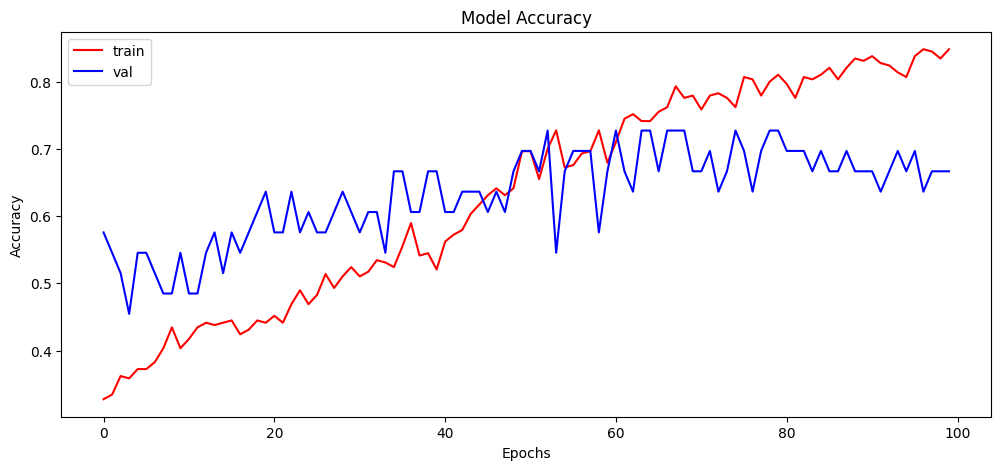

In [18]:
# plot the training history

plt.figure(figsize = (12, 5))
plt.plot(history.history['accuracy'], color = 'r')
plt.plot(history.history['val_accuracy'], color='b')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'val'])

plt.show()

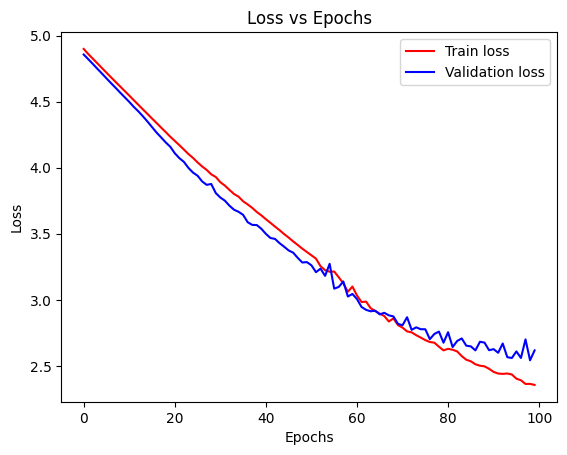

In [23]:
plt.plot(history.history['loss'], color = 'r', label= 'Train loss')
plt.plot(history.history['val_loss'], color = 'b', label = 'Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.legend()
plt.show()

In [19]:
y_pred = model.predict(x_test)
score = model.evaluate(x_test, y_test)
print('Accuracy over the test set: \n ', round((score[1]*100), 2), '%')

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 227ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - accuracy: 0.7778 - loss: 2.5656
Accuracy over the test set: 
  77.78 %


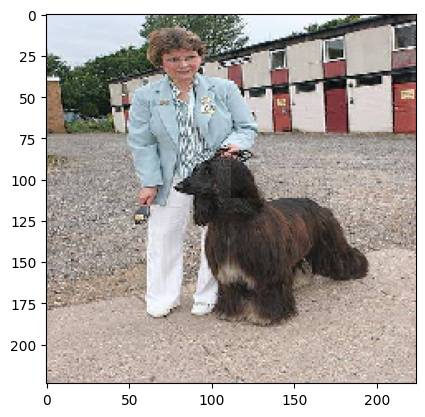

Originally :  scottish_deerhound
Predicted :  scottish_deerhound


In [20]:
# Plotting image to compare
plt.imshow(x_test[1,:,:,:])
plt.show()

# Finding max value from predition list and comaparing original value vs predicted
print("Originally : ",labels['breed'][np.argmax(y_test[1])])
print("Predicted : ",labels['breed'][np.argmax(y_pred[1])])

In [21]:
model.save('dog_breed.h5')